In [1]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "7"
import torch
import pandas as pd
import scanpy as sc
import warnings
from sigma.toolkit import set_seed
from sigma.toolkit import clustering
from sigma.data.preparation import build_spatial_triplet_inputs, prepare_rna_protein_features
import matplotlib.pyplot as plt
set_seed(2024)
warnings.filterwarnings('ignore')
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
print(device)
file_fold = '../SIGMA_data/10x_human_lymph_node_A1/'
adata_omics1 = sc.read_h5ad(file_fold + 'adata_RNA.h5ad')
adata_omics2 = sc.read_h5ad(file_fold + 'adata_ADT.h5ad')
adata_omics1.var_names_make_unique()
adata_omics2.var_names_make_unique()
adata_adt_raw = adata_omics2.copy()
adata_omics1.obs["anno"]=pd.read_csv(file_fold+"annotation.csv",index_col=0)["manual-anno"]
adata_omics1,adata_omics2


/opt/miniconda/envs/smart_new/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


cuda:0


(AnnData object with n_obs × n_vars = 3484 × 18085
     obs: 'anno'
     var: 'gene_ids', 'feature_types', 'genome'
     obsm: 'spatial',
 AnnData object with n_obs × n_vars = 3484 × 31
     var: 'gene_ids', 'feature_types', 'genome'
     obsm: 'spatial')

In [2]:
adata_omics1, adata_omics2, adata_list = prepare_rna_protein_features(
    adata_rna=adata_omics1,
    adata_protein=adata_omics2,
    min_cells=10,
    n_top_genes=3000,
    rna_n_comps=30,
    protein_n_comps=30,
)
x, edges, triplet_samples_list = build_spatial_triplet_inputs(
    adata_list=adata_list,
    rna_adata=adata_omics1,
    device=device,
    n_neighbors=6,
    edge_ratio=0.005,
    triplet_neighbors=3,
    farthest_ratio=0.6,
)


The graph contains 20904 edges, 3484 cells.
6.0000 neighbors per cell on average.
The graph contains 20904 edges, 3484 cells.
6.0000 neighbors per cell on average.
Original edges: 20904, planned new edges: 104
Actual directed new edges after deduplication: 162
  Final modality edge count: 21066
  Final modality edge count: 21066
Distances calculation completed!
The data using feature 'feat' contains 2732 mnn_anchors
Distances calculation completed!
The data using feature 'feat' contains 3358 mnn_anchors


In [3]:
from sigma.training import fit_sigma_embedding
model = fit_sigma_embedding(
    adata=adata_omics1,
    features=x,
    edges=edges,
    triplet_samples_list=triplet_samples_list,
    weights=[1, 1, 1, 1],
    emb_dim=64,
    n_epochs=600,
    lr=3e-4,
    weight_decay=2e-6,
    device=device,
    window_size=10,
    slope=1e-4,
    seed=2024,
    move_model_to=device,
    forward_kwargs={"alpha": 0.05},
)
from sigma.reporting import cluster_and_score_ari
tool = 'mclust'  # mclust, leiden, and louvain
ari = cluster_and_score_ari(
    adata_omics1,
    label_key='anno',
    cluster_key='SIGMA',
    embedding_key='SIGMA',
    n_clusters=7,
    method=tool,
    use_pca=True,
)


 75%|███████▍  | 449/600 [00:43<00:14, 10.23it/s]


Early stopping at epoch 450: tri_slope=-0.000084, rec_slope=-0.000019


R[write to console]:                    __           __ 
   ____ ___  _____/ /_  _______/ /_
  / __ `__ \/ ___/ / / / / ___/ __/
 / / / / / / /__/ / /_/ (__  ) /_  
/_/ /_/ /_/\___/_/\__,_/____/\__/   version 6.1.2
Type 'citation("mclust")' for citing this R package in publications.



fitting ...
  |======================================================================| 100%
0.38993909541187904


In [4]:
from sigma.reporting import report_clustering_metrics
tool = 'mclust'
scores = report_clustering_metrics(
    adata_omics1,
    label_key='anno',
    cluster_key='SIGMA',
    embedding_key='SIGMA',
    n_clusters=7,
    method=tool,
    use_pca=True,
)
ari = scores["ARI"]


fitting ...
  |======================================================================| 100%
ARI: 0.3899
NMI: 0.4586
AMI: 0.4560
Homo: 0.4482
V-measure: 0.4586
FMI: 0.5355
MI: 0.7561


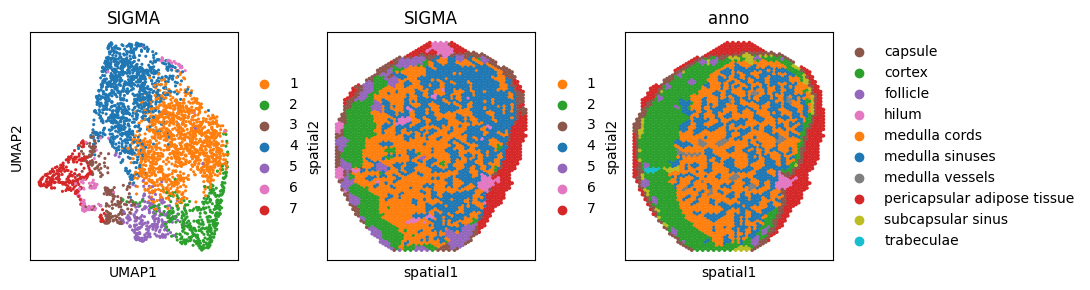

In [5]:
from sigma.reporting import mapped_annotation_palettes
import matplotlib.pyplot as plt
import scanpy as sc
fig, ax_list = plt.subplots(1, 3, figsize=(11, 3))
sc.pp.neighbors(adata_omics1, use_rep='SIGMA', n_neighbors=10)
sc.tl.umap(adata_omics1)
colors = [
    '#1f77b4',  # blue
    '#ff7f0e',  # orange
    '#2ca02c',  # green
    '#d62728',  # red
    '#9467bd',  # purple
    '#8c564b',  # brown
    '#e377c2',  # pink
    '#7f7f7f',  # gray
    '#bcbd22',  # yellow
    '#17becf',  # cyan
    '#4a90e2',  # dark blue
    '#f5a623',  # dark orange
    '#7ed321',  # dark green
    '#d0021b',  # dark red
    '#8b6bbf',  # dark purple
    '#a7a8aa',  # dark gray
]
colordict_anno, colordict_sigma = mapped_annotation_palettes(
    adata_omics1,
    cluster_key="SIGMA",
    label_key="anno",
    colors=colors,
)
sc.pl.umap(
    adata_omics1,
    color='SIGMA',
    ax=ax_list[0],
    title='SIGMA',
    s=20,
    palette=colordict_sigma,
    show=False
)
sc.pl.embedding(
    adata_omics1,
    basis='spatial',
    color='SIGMA',
    ax=ax_list[1],
    title='SIGMA',
    s=30,
    palette=colordict_sigma,
    show=False
)
sc.pl.embedding(
    adata_omics1,
    basis='spatial',
    color='anno',
    ax=ax_list[2],
    title='anno',
    s=30,
    palette=colordict_anno,
    show=False
)
plt.tight_layout(w_pad=0.3)
plt.show()


In [6]:
# ========== Moran's I for Current Method: SIGMA ==========
import pandas as pd
import scanpy as sc
import squidpy as sq
from sigma.toolkit import clustering
# =====================================================
# 1. Generate clustering using SIGMA embedding
# =====================================================
cluster1 = 5
cluster2 = 11
print("\nGenerating SIGMA clustering...")
for n_cluster in range(cluster1, cluster2):
    cluster_col = f"SIGMA_{n_cluster}"
    clustering(
        adata_omics1,
        key='SIGMA',
        add_key=cluster_col,
        n_clusters=n_cluster,
        method='mclust',
        use_pca=True
    )
    print(
        cluster_col,
        "actual clusters =",
        adata_omics1.obs[cluster_col].nunique()
    )
# =====================================================
# 2. Build spatial graph
# =====================================================
if "spatial" not in adata_omics1.obsm:
    raise ValueError("adata_omics1.obsm['spatial'] not found")
print("\nBuilding spatial graph...")
sc.pp.neighbors(
    adata_omics1,
    use_rep="spatial",
    n_neighbors=10
)
# =====================================================
# 3. Compute Moran's I
# =====================================================
sigma_moran = []
print("\nComputing Moran's I...")
for i in range(cluster1, cluster2):
    cluster_col = f"SIGMA_{i}"
    if cluster_col not in adata_omics1.obs:
        continue
    adata_omics1.obs[cluster_col] = (
        adata_omics1.obs[cluster_col]
        .astype(int)
    )
    r = sq.gr.spatial_autocorr(
        adata_omics1,
        connectivity_key='connectivities',
        genes=[cluster_col],
        mode='moran',
        attr="obs",
        copy=True
    )
    morans_i = r["I"][0]
    sigma_moran.append({
        "method": "SIGMA",
        "cluster": i,
        "morans_i": morans_i
    })
    print(f"{cluster_col}: Moran's I = {morans_i:.6f}")
df_sigma = pd.DataFrame(sigma_moran)
# =====================================================
# 4. Output results
# =====================================================
print("\n" + "=" * 60)
print("Current Method Moran's I")
print("=" * 60)
print(df_sigma.to_string(index=False))
print("=" * 60)
# Optional: save the results
# df_sigma.to_csv("SIGMA_Moran_only.csv", index=False)



Generating SIGMA clustering...
fitting ...
  |======================================================================| 100%
SIGMA_5 actual clusters = 5
fitting ...
  |======================================================================| 100%
SIGMA_6 actual clusters = 6
fitting ...
  |======================================================================| 100%
SIGMA_7 actual clusters = 7
fitting ...
  |======================================================================| 100%
SIGMA_8 actual clusters = 8
fitting ...
  |======================================================================| 100%
SIGMA_9 actual clusters = 9
fitting ...
  |======================================================================| 100%
SIGMA_10 actual clusters = 10

Building spatial graph...

Computing Moran's I...
SIGMA_5: Moran's I = 0.857002
SIGMA_6: Moran's I = 0.560834
SIGMA_7: Moran's I = 0.622860
SIGMA_8: Moran's I = 0.670715
SIGMA_9: Moran's I = 0.600306
SIGMA_10: Moran's I = 0.474506

Current Metho

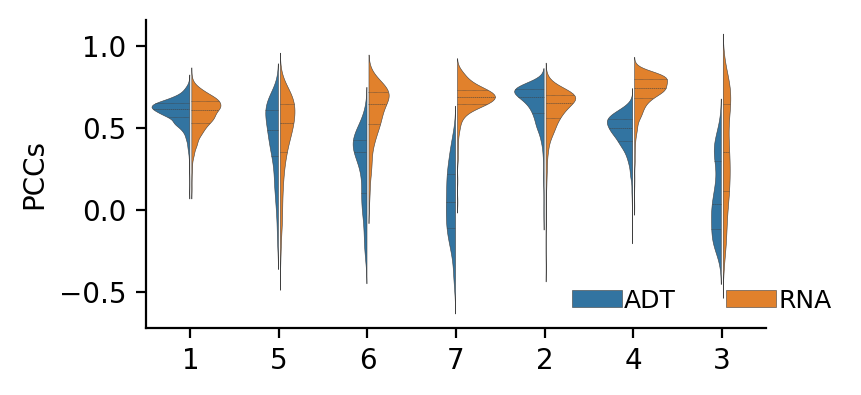

In [7]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import pairwise_distances
from scipy.stats import pearsonr
# =====================================================
# embeddings
# =====================================================
sigma_emb = adata_omics1.obsm["SIGMA"]
rna_emb = adata_omics1.obsm["feat"]
adt_emb = adata_omics2.obsm["feat"]
# =====================================================
# cluster labels
# =====================================================
cluster_labels = (
    adata_omics1.obs["SIGMA_7"]
    .astype(int)
    .values
)
# =====================================================
# pairwise distance matrix
# =====================================================
dis_sigma = pairwise_distances(sigma_emb)
dis_rna = pairwise_distances(rna_emb)
dis_adt = pairwise_distances(adt_emb)
# =====================================================
# compute spot-wise PCC
# =====================================================
df = pd.DataFrame(
    columns=[
        "cluster",
        "modality",
        "pearsonr"
    ]
)
for i, cluster_id in enumerate(cluster_labels):
    # SIGMA vs RNA
    corr_rna, _ = pearsonr(
        dis_sigma[i],
        dis_rna[i]
    )
    df.loc[len(df)] = [
        cluster_id,
        "RNA",
        corr_rna
    ]
    # SIGMA vs ADT
    corr_adt, _ = pearsonr(
        dis_sigma[i],
        dis_adt[i]
    )
    df.loc[len(df)] = [
        cluster_id,
        "ADT",
        corr_adt
    ]
# =====================================================
# cluster order
# =====================================================
# order = (
#     df.groupby("cluster")["pearsonr"]
#     .median()
#     .sort_values(ascending=False)
#     .index
# )
order=[1,5,6,7,2,4,3]
# =====================================================
# plot
# =====================================================
fig, ax = plt.subplots(
    figsize=(4,2),
    dpi=200
)
sns.violinplot(
    data=df,
    x="cluster",
    y="pearsonr",
    hue="modality",
    split=True,
    gap=0.05,
    inner="quart",
    linewidth=0.2,
    width=0.9,
    order=order,
    hue_order=["ADT","RNA"],
    palette={
        "ADT":"#1f77b4",
        "RNA":"#ff7f0e"
    }
)
ax.set_ylabel("PCCs")
ax.set_xlabel("")
# ax.set_ylim(-0.5,1.0)
# ax.set_yticks([-0.5,0.0,0.5,1.0])
ax.legend(
    bbox_to_anchor=(0.65,0.2),
    frameon=False,
    ncol=3,
    labelspacing=0.2,
    handletextpad=0.1,
    fontsize=9
)
sns.despine()
fig.savefig(
    "PCCs2.svg",
    format="svg",
    bbox_inches='tight',
    transparent=True
)
plt.show()


In [8]:
from sigma.toolkit import clustering
tool = "mclust"
clustering(
    adata_omics1,
    key="SIGMA",
    add_key="SIGMA_6",
    n_clusters=6,
    method=tool,
    use_pca=True,
)
adata_omics1.obs["SIGMA_6"] = (
    adata_omics1.obs["SIGMA_6"]
    .astype("category")
    .cat.remove_unused_categories()
)
print(adata_omics1.obs["SIGMA_6"].cat.categories)
print("cluster number:", adata_omics1.obs["SIGMA_6"].nunique())


fitting ...
  |======================================================================| 100%
Index([1, 2, 3, 4, 5, 6], dtype='int64')
cluster number: 6


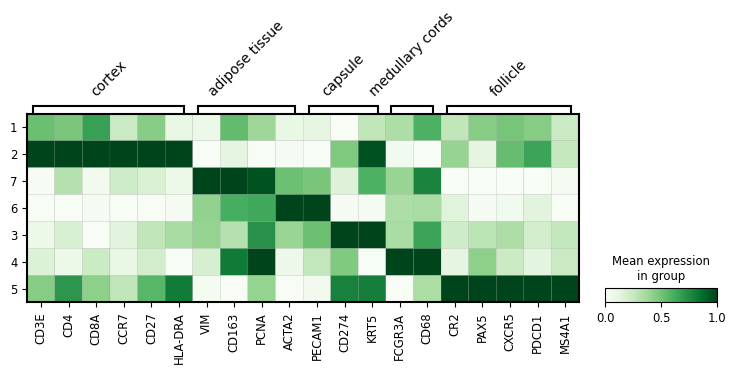

In [9]:
import muon.prot as pt
adata_adt = adata_adt_raw.copy()
adata_adt.obs["SIGMA"]=adata_omics1.obs["SIGMA_7"]
adata_adt.obs['SIGMA'] = adata_adt.obs['SIGMA'].astype('category')
#     .cat.reorder_categories(
#         [1,2,3,4,7,5,6],
#         ordered=True
#     )
# )
nonzero_cells = np.array((adata_adt.X.sum(axis=1) > 0)).flatten()
adata_adt = adata_adt[nonzero_cells].copy()
custom_order = ["1", "2", "7", "6", "3", "4", "5"]
adata_adt.obs["SIGMA"] = (
    adata_adt.obs["SIGMA"]
    .astype(str)
    .astype("category")
    .cat.remove_unused_categories()
    .cat.reorder_categories(custom_order, ordered=True)
)
pt.pp.clr(adata_adt)
sc.tl.rank_genes_groups(adata_adt, 'SIGMA', method='wilcoxon')  # calculate differentially expressed genes
rank_adt={
    "cortex": ["CD3E", "CD4", "CD8A", "CCR7",  "CD27", "HLA-DRA"],
    "adipose tissue": [ "VIM",'CD163','PCNA',"ACTA2" ],
    'capsule':['PECAM1','CD274','KRT5'],
    "medullary cords": ["FCGR3A","CD68" ],
    "follicle": ["CR2", "PAX5",  "CXCR5", "PDCD1", "MS4A1"],
}
mp = sc.pl.matrixplot(
    adata_adt,
    var_names=rank_adt,
    groupby="SIGMA",
    standard_scale="var",
    var_group_rotation=45,
    cmap="Greens",
    show=False,
)
plt.savefig(
    "ADT_SIGMA_matrixplot.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()


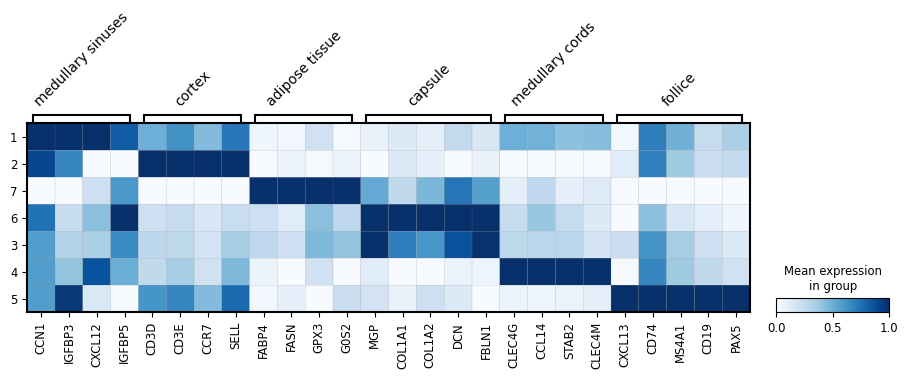

In [10]:
adata_rna = adata_omics1
adata_adt = adata_omics2
custom_order = ["1", "2", "7", "6", "3", "4", "5"]
adata_rna.obs["SIGMA"] = (
    adata_rna.obs["SIGMA"]
    .astype(str)
    .astype("category")
    .cat.reorder_categories(custom_order, ordered=True)
)
rank_genes={'medullary sinuses': ['CCN1', 'IGFBP3', 'CXCL12', 'IGFBP5'],
            'cortex': ["CD3D", "CD3E", "CCR7", "SELL"],
            'adipose tissue': ['FABP4', 'FASN', 'GPX3', 'G0S2'],
            "capsule": [ 'MGP',"COL1A1", "COL1A2", "DCN", "FBLN1"],
            'medullary cords': ['CLEC4G', 'CCL14', 'STAB2', 'CLEC4M'],
            'follice': ['CXCL13', 'CD74','MS4A1',"CD19",  "PAX5"],
            }
mp = sc.pl.matrixplot(
    adata_rna,
    var_names=rank_genes,
    groupby="SIGMA",
    standard_scale="var",
    var_group_rotation=45,
    cmap="Blues",
    show=False,
)
plt.savefig(
    "RNA_SIGMA_matrixplot.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()
